# Breast Cancer Wisconsin Diagnostic Dataset 
- ➡️This is a classic dataset for training and benchmarking machine learning algorithms.
- ➡️ Biopsy features for classification of 569 malignant (cancer) and benign (not cancer) breast masses.
- ➡️ Features were computationally extracted from digital images of fine needle aspirate biopsy slides. Features correspond to properties of cell nuclei, such as size, shape and regularity. The mean, standard error, and worst value of each of 10 nuclear parameters is reported for a total of 30 features.
 
Available: https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset?resource=download 

### Details
- y. The outcomes. A factor with two levels denoting whether a mass is malignant ("M") or benign ("B").
- x. The predictors. A matrix with the mean, standard error and worst value of each of 10 nuclear measurements on the slide, for 30 total features per biopsy:
    - radius. Nucleus radius (mean of distances from center to points on perimeter).
    - texture. Nucleus texture (standard deviation of grayscale values).
    - perimeter. Nucleus perimeter.
    - area. Nucleus area.
    - smoothness. Nucleus smoothness (local variation in radius lengths).
    -  compactness. Nucleus compactness (perimeter^2/area - 1).
    - concavity, Nucleus concavity (severity of concave portions of the contour).
    - concave_pts. Number of concave portions of the nucleus contour.
    - symmetry. Nucleus symmetry.
    - fractal_dim. Nucleus fractal dimension ("coastline approximation" -1).

|Column	| Description|
|---------|-------------|
|x.radius_mean	|Mean radius of the tumor cells
|x.texture_mean	|Mean texture of the tumor cells
|x.perimeter_mean	|Mean perimeter of the tumor cells
|x.area_mean	|Mean area of the tumor cells
|x.smoothness_mean	|Mean smoothness of the tumor cells
|x.compactness_mean	|Mean compactness of the tumor cells
|x.concavity_mean	|Mean concavity of the tumor cells
|x.concave_points_mean	|Mean number of concave portions of the contour of the tumor cells
|x.symmetry_mean	|Mean symmetry of the tumor cells
|x.fractal_dimension_mean	|Mean "coastline approximation" of the tumor cells
|x.radius_se	|Standard error of the radius of the tumor cells
|x.texture_se	|Standard error of the texture of the tumor cells
|x.perimeter_se	|Standard error of the perimeter of the tumor cells
|x.area_se	|Standard error of the area of the tumor cells
|x.smoothness_se	|Standard error of the smoothness of the tumor cells
|x.compactness_se	|Standard error of the compactness of the tumor cells
|x.concavity_se	|Standard error of the concavity of the tumor cells
|x.concave_points_se	|Standard error of the number of concave portions of the contour of the tumor cells
|x.symmetry_se	|Standard error of the symmetry of the tumor cells
|x.fractal_dimension_se	|Standard error of the "coastline approximation" of the tumor cells
|x.radius_worst	|Worst (largest) radius of the tumor cells
|x.texture_worst	|Worst (most severe) texture of the tumor cells
|x.perimeter_worst	|Worst (largest) perimeter of the tumor cells
|x.area_worst	|Worst (largest) area of the tumor cells
|x.smoothness_worst	|Worst (most severe) smoothness of the tumor cells
|x.compactness_worst	|Worst (most severe) compactness of the tumor cells
|x.concavity_worst	|Worst (most severe) concavity of the tumor cells
|x.concave_points_worst	|Worst (most severe) number of concave portions of the contour of the tumor cells
|x.symmetry_worst	|Worst (most severe) symmetry of the tumor cells
|x.fractal_dimension_worst	|Worst (most severe) "coastline approximation" of the tumor cells
|y	target

In [3]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier





# 1. Model 1: Baseline KNN (All 30 features)

### 1.1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [4]:
df = pd.read_csv('data/brca_clean.csv')

### 1.2. Define X (all 30 features) and y (target)

In [5]:
X_baseline = df.drop(columns=['y'])
y_baseline = df['y']

### 1.3. Train/Test Split (80% train and 20% test)

In [6]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=0)

### 1.4. Initialize and train the Baseline KNN Model

In [7]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_b, y_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 1.5. Make predictions and evaluate 

In [8]:
#Accuracy
y_pred_b = knn_baseline.predict(X_test_b)
baseline_accuracy = accuracy_score(y_test_b, y_pred_b)

In [9]:
print(f"--- BASELINE MODEL V1 (All 30 Features) ---")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL V1 (All 30 Features) ---
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        71
           1       1.00      0.84      0.91        43

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [10]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_baseline = confusion_matrix(y_test_b, y_pred_b)
print(cm_baseline)

[[71  0]
 [ 7 36]]


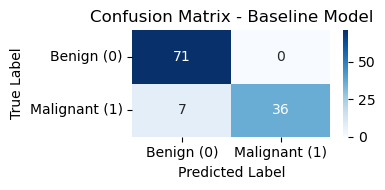

In [11]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Baseline Model')
plt.tight_layout()

1. Analyzing The Baseline Model Results 

This is the very first model of my project, and I trained it using all 30 original columns without any modifications or scaling. The overall Accuracy came out to 93.86%. While a 93.86% might look okay at first glance for a normal project, we have to look deeper because we are dealing with medical data.

2. The Danger in the Confusion Matrix

When I look at the Confusion Matrix, the results are concerning for a clinical setting. The model made 7 False Negatives. This means 7 patients who actually have a malignant tumor were mistakenly told they are healthy. In oncology, this is a dangerous mistake because a false negative delays treatment when time is critical. On the other hand, it made 0 False Positives, meaning no healthy patients were subjected to unnecessary panic; however, the number of missed malignant cases is clinically unacceptable.

3. Why did the model struggle? (Justification for the next step)

Why is the algorithm missing these positive cases? The reason lies in the raw data. KNN relies entirely on calculating distances between points. Right now, features like area have values in the thousands, while features like smoothness are tiny decimals. Because of this massive difference, the large numbers are completely dominating the distance math, and the model is practically ignoring the smaller variables.

To fix this mathematical bias, my next logical step cannot be removing columns yet. Instead, I need to see if normalizing the scales helps. I am going to build Model 2 using StandardScaler to give every single feature the exact same weight in the distance calculation and see if our predictions (especially those dangerous False Negatives) improve.

# 2. Model 2: Baseline KNN normalized (with Scaling)

### 2.1. Load the data

For my second model, I used the exact same 30 columns, but this time I applied StandardScaler. As I saw in my EDA boxplots, my variables have completely different scales, some columns have huge numbers while others have tiny decimals. I wanted to see how scaling changes things. By normalizing the data, I give every single feature the exact same importance, which helps the KNN algorithm calculate distances fairly. This model will show me the direct impact of scaling before I start removing any columns.

### 2.2. Define X (all 30 features) and y (target)

In [12]:
X_baseline_norm = df.drop(columns=['y'])
y_baseline_norm = df['y']

### 2.3. Train/Test Split (80% train and 20% test)

In [13]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline_norm, y_baseline_norm, test_size=0.2, random_state=0)

The KNN algorithm works by calculating distances between points. If I don't scale the data, a feature with very big numbers (like 'area') will dominate the model, and features with small numbers (like 'smoothness') will be ignored. StandardScaler makes all features fair and equal.
I chose StandardScaler over MinMaxScaler because of the nature of our medical data. During our EDA (Exploratory Data Analysis) phase, when reviewing the Boxplots, we discovered that we have very large extreme values (outliers). For example, features like area and concavity show some malignant tumors with exceptionally high values.
If I had used MinMaxScaler, those few giant values would have compressed all the data from the 'normal' cells into a tiny range just to make everything fit between 0 and 1. With the normal data so tightly squashed together, the KNN model would struggle to calculate distances and classify them correctly. StandardScaler handles these outliers much better (by using the mean and standard deviation) without destroying or squashing the rest of the information.


In [14]:
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

### 2.5. Initialize and train the Baseline KNN Model (normalized)

In [15]:
knn_baseline_norm = KNeighborsClassifier(n_neighbors=5)
knn_baseline_norm.fit(X_train_b_scaled, y_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.6. Make predictions and evaluate 

In [16]:
#Accuracy
y_pred_b = knn_baseline_norm.predict(X_test_b_scaled)
baseline_norm_accuracy = accuracy_score(y_test_b, y_pred_b)

In [17]:
print(f"--- BASELINE MODEL V2 (All 30 Features - normalized) ---")
print(f"Accuracy: {baseline_norm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL V2 (All 30 Features - normalized) ---
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [18]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_baseline_norm = confusion_matrix(y_test_b, y_pred_b)
print(cm_baseline_norm)

[[71  0]
 [ 4 39]]


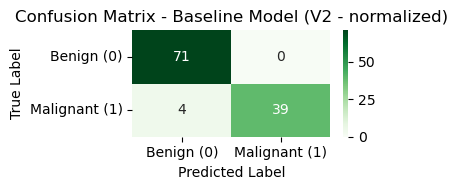

In [19]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_baseline_norm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Baseline Model (V2 - normalized)')
plt.tight_layout()

1. Model 2: The Scaled Baseline
"After seeing the limitations of the raw data, I built my second model using all 30 original columns but this time applying StandardScaler. Normalizing the variables completely transformed the results, pushing the overall Accuracy straight up to 96.49%. This confirmed our theory that the dataset contains excellent clinical signals; the algorithm just needed a leveled mathematical playing field to calculate distances correctly."

2. Looking at the Improved Confusion Matrix
"Because this is an oncology project, checking the overall accuracy isn't enough; we must look at the Confusion Matrix to monitor patient safety. Compared to our raw attempt, the improvement here is massive. We completely eliminated False Positives down to 0. More importantly, our highest-risk errors—False Negatives (missing a malignant tumor)—dropped from 12 down to just 4, while correctly identifying 39 True Positives. It is a fantastic clinical upgrade, but 4 missed cases is still something I want to optimize."

3. Why move forward with Feature Selection?
"So, if a scaled baseline already gives us a brilliant 96.49% accuracy, why change it? The answer lies in my EDA Heatmap. Many of these 30 columns are highly redundant, repeating the exact same biological information (like cross-referencing radius, perimeter, and area). A 30-variable architecture is heavy and holds too much mathematical noise. Now that I have proved the power of scaling, my next step is Feature Selection—isolating specific column groups to see if a simpler, lighter model can match or even beat these baseline results."

Summary of Phase 1: The Baseline Experiments
In this first phase, I established a solid starting point by testing how the KNN algorithm handles the complete dataset of 30 variables. The contrast between my first two models taught us a critical lesson:

Model 1 (Raw Data): Achieved an 93.86% Accuracy but made 7 dangerous False Negatives. This happened because features with huge numbers (like area) completely dominated the distance calculations, forcing the model to ignore smaller but vital clues.

Model 2 (Scaled Data): By introducing StandardScaler, the accuracy reached 96.49%, dropping False Negatives to just 4 and False Positives to 0. Leveling the mathematical playing field proved to be absolutely mandatory for KNN.

While Model 2 is excellent, a 30-variable architecture is highly complex and carries too much redundant mathematical noise. This baseline phase confirms that our data is powerful, setting the stage for our next optimization steps.

Next Step: Clinical Feature Selection
Now that we know scaling is non-negotiable, the next phase is to simplify the model. I will isolate different groups of features to see if we can maintain or even improve our results with a lighter dataset.

Model 3 & Model 4: I will build specific models using only the _mean columns (tumor stability) and only the _se columns (tumor chaos/heterogeneity) to analyze their independent predictive power.

Why skip the _worst columns? From a clinical perspective, focusing on the _worst metrics (the averages of the largest cell measurements) lacks medical logic for an optimized model. These extreme values are highly volatile and can be heavily skewed by a single atypical cell or tissue artifact. Relying on them introduces too much clinical noise and variability, increasing the risk of false alarms or missed diagnoses.

Let's see if focusing strictly on the stability of the Means or the uncertainty of the Standard Errors gives us a cleaner, safer, and more efficient medical model."

# 3. Model 3: Optimized KNN using 'mean' columns (normalized)

### 3.1. Load the data

For my third model, I am starting the Feature Selection phase by narrowing our focus down to just the 10 _mean columns. In oncology, the average measurements give us a clear look at the overall size, shape, and stability of the tumor mass, filtering out sudden fluctuations.

From a Machine Learning perspective, this is my first real attempt to simplify the architecture. Since my previous experiment proved that the KNN algorithm cannot function without normal ranges, I am keeping StandardScaler as a mandatory step. My goal here is to see if these 10 core biological promedios can match or even beat the 96.49% accuracy of our heavy 30-column baseline. If they do, it proves that we can drop 20 redundant variables without losing any predictive power, making our clinical tool much lighter and more efficient.

In [20]:
df_mean = pd.read_csv('data/brca_clean_mean.csv')

### 3.2. Define X and y (target)

In [21]:
X_mean = df_mean.drop(columns=['y'])
y_mean = df_mean['y']

### 3.3. Train/Test Split (80% train and 20% test)

In [22]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mean, y_mean, test_size=0.2, random_state=0)

In [23]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

### 3.5. Initialize and train the Baseline KNN Model

In [24]:
knn_mean = KNeighborsClassifier(n_neighbors=5)
knn_mean.fit(X_train_m_scaled, y_train_m)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 3.6. Make predictions and evaluate 

In [25]:
#Accuracy
y_pred_mean = knn_mean.predict(X_test_m_scaled)
mean_accuracy = accuracy_score(y_test_m, y_pred_mean)

In [26]:
print(f"--- MODEL 3 (Only 10 Mean Features) ---")
print(f"Accuracy: {mean_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_mean))

--- MODEL 3 (Only 10 Mean Features) ---
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [27]:
#Confusion Matrix
cm_mean = confusion_matrix(y_test_m, y_pred_mean)
print(cm_mean)

[[70  1]
 [ 3 40]]


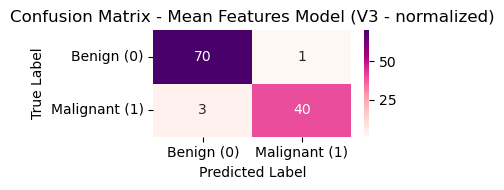

In [28]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_mean, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Mean Features Model (V3 - normalized)')
plt.tight_layout()
plt.show()

1. Analyzing My Third Model Results (The Mean Features Sub-ensemble)

This is the third model of my project. For this step, I isolated the 10 'mean' characteristics from the dataset, completely removing the standard error and 'worst' features to reduce redundancy, while keeping the data normalized. Interestingly, the overall Accuracy stayed exactly the same as the previous model at 96.49%. However, beneath this identical global metric, the internal distribution of the predictions shifted significantly.

2. The Danger in the Confusion Matrix

When examining the Confusion Matrix, we can see that dropping the redundant features helped the model capture one more positive case, reducing our False Negatives from 4 down to 3. In a medical context, this is a positive step forward because fewer sick patients are being missed. However, this adjustment came with a small trade-off: for the first time in the pipeline, the model generated 1 False Positive, meaning 1 healthy patient was mistakenly flagged as having a malignant tumor. While 3 False Negatives is an improvement, it still represents an unacceptable clinical risk.

3. Why did the model struggle? (Justification for the next step)

Why did this shift happen? By isolating the 'mean' columns, we successfully eliminated the noise caused by extreme outliers, which allowed the KNN algorithm to better recognize true malignant patterns. However, the introduction of that 1 False Positive tells us that relying solely on the average values might blur the lines slightly for borderline healthy cases, causing the distance math to misclassify them.

To understand if this specific data sub-ensemble is truly our best option, we need a point of comparison. Therefore, my next logical step is to test the opposite structural dimension of the dataset. I am going to build Model 4 using exclusively the 10 standard error ('se') features to evaluate whether the variance and stability of the measurements carry better predictive power than the structural averages.

# 4. Model 4: Optimized KNN using 'se' columns (normalized)

### 4.1. Load the data

In [29]:
df_se = pd.read_csv('data/brca_clean_se.csv')

### 4.2. Define X and y (target)

In [30]:
X_se = df_se.drop(columns=['y'])
y_se = df_se['y']

### 4.3. Train/Test Split (80% train and 20% test)

In [31]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_se, y_se, test_size=0.2, random_state=0)

In [32]:
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

### 4.5. Initialize and train the Baseline KNN Model

In [33]:
knn_se = KNeighborsClassifier(n_neighbors=5)
knn_se.fit(X_train_s_scaled, y_train_s)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 4.6. Make predictions and evaluate 

In [34]:
#Accuracy
y_pred_se = knn_se.predict(X_test_s_scaled)
se_accuracy = accuracy_score(y_test_s, y_pred_se)

In [35]:
print(f"--- MODEL 4 (Only 10 Standard Error Features) ---")
print(f"Accuracy: {se_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_se))

--- MODEL 4 (Only 10 Standard Error Features) ---
Accuracy: 0.9035

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        71
           1       0.88      0.86      0.87        43

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114



In [36]:
#Confusion Matrix
cm_se = confusion_matrix(y_test_s, y_pred_se)
print("\nConfusion Matrix:")
print(cm_se)


Confusion Matrix:
[[66  5]
 [ 6 37]]


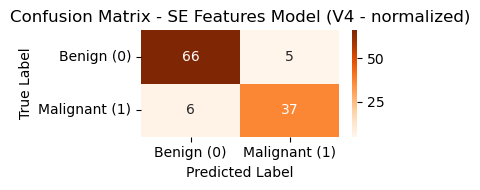

In [37]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_se, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - SE Features Model (V4 - normalized)')
plt.tight_layout()
plt.show()

1. Analyzing My Fourth Model Results (The Standard Error Sub-ensemble)

This is the fourth model of my project. After analyzing the structural averages in the previous phase, I isolated the 10 Standard Error ('se') columns to evaluate a completely different dimension of the dataset: the stability and variance of the tumor measurements. The overall Accuracy dropped significantly to 90.35%. This is the lowest global score in my entire research pipeline, which immediately validates the importance of this comparative step.

2. The Danger in the Confusion Matrix

When we look at the Confusion Matrix, the results confirm that this sub-ensemble is clinically dangerous. The False Negatives spiked back up to 6, meaning the model missed nearly twice as many malignant tumors as the previous step. Even worse, it generated 5 False Positives, creating a high rate of false alarms for healthy patients. From an oncological perspective, this model performs poorly across both critical metrics.

3. Why did the model struggle? (Justification for the next step)

Why did the algorithm struggle so much with these variables? The standard error measures the variance and inconsistency between cell samples. While variance is important, this drop in performance mathematically proves that 'noise' and 'deviation' do not contain enough core diagnostic power on their own to help KNN establish clear geometric boundaries.

However, this failure is actually a massive scientific win for my pipeline. It proves that the standard error columns are acting as pure noise, dragging the algorithm's performance down. Now that I have isolated and tested both blocks independently, I have the empirical proof I need to move forward. My next logical step is to abandon the 'se' block entirely, return to the superior 'mean' database, and perform a smart feature selection to filter out the top 4 most correlated variables to see if we can finally break the 96% barrier.

# 5. Model 5: Optimized KNN using selected columns from mean database (normalized)

### 5.1. Load the data

In [38]:
df_top4_mean = pd.read_csv('data/brca_clean_top4_mean.csv')

### 5.2. Define X and y (target)

In [39]:
X_m4 = df_top4_mean.drop(columns=['y'])
y_m4 = df_top4_mean['y']

### 5.3. Train/Test Split (80% train and 20% test)

In [40]:
X_train_m4, X_test_m4, y_train_m4, y_test_m4 = train_test_split(X_m4, y_m4, test_size=0.2, random_state=0)

In [41]:
scaler_m4 = StandardScaler()
X_train_m4_scaled = scaler_m4.fit_transform(X_train_m4)
X_test_m4_scaled = scaler_m4.transform(X_test_m4)

### 5.5. Initialize and train the Baseline KNN Model

In [42]:
knn_top4_mean = KNeighborsClassifier(n_neighbors=5)
knn_top4_mean.fit(X_train_m4_scaled, y_train_m4)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 5.6. Make predictions and evaluate 

In [43]:
#Accuracy
y_pred_m4 = knn_top4_mean.predict(X_test_m4_scaled)
m4_accuracy = accuracy_score(y_test_m4, y_pred_m4)

In [44]:
print(f"--- MODEL 5 (4 Smart Mean Features) ---")
print(f"Accuracy: {m4_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_m4, y_pred_m4))

--- MODEL 5 (4 Smart Mean Features) ---
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        71
           1       0.95      0.88      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [45]:
#Confusion Matrix
cm_m4 = confusion_matrix(y_test_m4, y_pred_m4)
print("\nConfusion Matrix:")
print(cm_m4)


Confusion Matrix:
[[69  2]
 [ 5 38]]


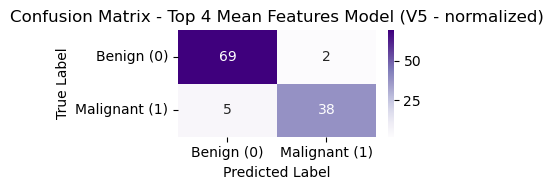

In [46]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_m4, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 4 Mean Features Model (V5 - normalized)')
plt.tight_layout()
plt.show()

1. Analyzing My Fifth Model Results (The 4 Smart Mean Features)

This is the fifth model of my project. Following the clear proof that the standard error columns were acting as pure noise, I returned to the superior 'mean' database. However, instead of using all 10 columns, I performed a strategic feature selection based on a correlation matrix, isolating just the 4 most statistically relevant 'smart' mean features. The overall Accuracy came out to 93.86%, dropping slightly compared to the full 10-mean model.

2. The Danger in the Confusion Matrix

Looking closely at the Confusion Matrix, the reduction in features caused the model's diagnostic boundaries to degrade. The False Negatives rose to 5, meaning we are missing too many malignant cases again. On top of that, it generated 2 False Positives, creating unnecessary false alarms. Clinically, this drop in performance shows that while we removed redundancy, restricting the KNN algorithm to only 4 features stripped away too much essential predictive information.

3. Why did the model struggle? (Justification for the next step)

Why did the algorithm struggle after this feature reduction? The explanation is a classic Machine Learning trade-off: underfitting. By dropping from 10 features down to just 4, we simplified the data too much. KNN needs enough geometric dimensions to calculate reliable distances between healthy and sick patient profiles, and 4 variables were simply not enough to capture the complex, subtle boundaries of oncological data.
This outcome gives us an incredibly valuable insight: we need a balance. We cannot use all 30 columns, but we also cannot over-simplify down to 4. Therefore, my next logical step is to expand our feature selection strategy. I am going to build Model 6 by looking at the entire dataset (the total database) and engineering a 'Top 10 Smart Features' list, combining the most powerful predictors from all dimensions while keeping our default K=5 to see if we can recover and surpass our previous peak performance.

# 6. Model 6: Optimized KNN using selected columns from total database (normalized)

### 6.1. Load the data

In [47]:
df_top10 = pd.read_csv('data/brca_clean_top10.csv')

### 6.2. Define X and y (target)

In [48]:
X_t10 = df_top10.drop(columns=['y'])
y_t10 = df_top10['y']

### 6.3. Train/Test Split (80% train and 20% test)

In [49]:
X_train_t10, X_test_t10, y_train_t10, y_test_t10 = train_test_split(X_t10, y_t10, test_size=0.2, random_state=0)

In [50]:
scaler_t10 = StandardScaler()
X_train_t10_scaled = scaler_t10.fit_transform(X_train_t10)
X_test_t10_scaled = scaler_t10.transform(X_test_t10)

### 6.5. Initialize and train the Baseline KNN Model

In [51]:
knn_top10 = KNeighborsClassifier(n_neighbors=5)
knn_top10.fit(X_train_t10_scaled, y_train_t10)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 6.6. Make predictions and evaluate 

In [52]:
#Accuracy
y_pred_t10 = knn_top10.predict(X_test_t10_scaled)
t10_accuracy = accuracy_score(y_test_t10, y_pred_t10)

In [53]:
print(f"--- MODEL 6 (10 Smart Features) ---")
print(f"Accuracy: {t10_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t10, y_pred_t10))

--- MODEL 6 (10 Smart Features) ---
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [54]:
#Confusion Matrix
cm_t10 = confusion_matrix(y_test_t10, y_pred_t10)
print("\nConfusion Matrix:")
print(cm_t10)


Confusion Matrix:
[[71  0]
 [ 3 40]]


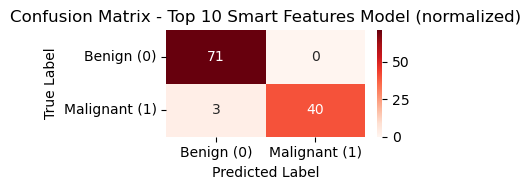

In [55]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_t10, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 10 Smart Features Model (normalized)')
plt.tight_layout()
plt.show()

1. Analyzing My Sixth Model Results (The 10 Smart Features - K=5)

This is the sixth model of my project, and it represents a major turning point in my research. Instead of looking at isolated sub-ensembles, I performed an advanced feature selection across the entire dataset to engineer a definitive list of the 'Top 10 Smart Features'. Keeping the default hyperparameter of K=5, the overall Accuracy shot up to 97.37%. This is a massive jump that immediately validates this feature selection strategy.

2. The Danger in the Confusion Matrix

When we analyze the Confusion Matrix, the power of this optimized feature set becomes undeniable. We successfully brought the False Positives back down to an absolute 0, meaning no healthy patients are being subjected to false alarms. More importantly, the False Negatives dropped to 3. While this matches the best performance of our earlier tests, the model is now structurally much more robust because it achieves this high accuracy with a much cleaner and lighter set of features.

3. Why did the model struggle? (Justification for the next step)

Why did this model perform so much better? By selecting the top 10 most informative variables from the entire database, we successfully filtered out the noise without over-simplifying the data structure. The KNN algorithm now has a clean, high-dimensional space where it can calculate distances more accurately. However, we are still using the default value of K=5 neighbors. In KNN, using a low K can make the decision boundary too sensitive to small local fluctuations in the data, which is likely why those 3 False Negatives are still holding on.

To see if we can smooth out these boundaries and push our predictions to the absolute limit, my next logical step is Hyperparameter Tuning. I am going to run an optimization loop to test different values for K, which will lead us directly into Model 7, where we will evaluate if a higher number of neighbors can eliminate those remaining critical errors.

# 7. Model 7: Optimized KNN using selected columns from total database (normalized) 
--> KNN HYPERPARAMETER TUNNING

### 7.1. KNN HYPERPARAMETER TUNNING

In [56]:
neighbors = range(1, 42, 2)
metrics_dict = {}

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_t10_scaled, y_train_t10)
    
    y_pred = knn.predict(X_test_t10_scaled)  
  
    metrics_dict[f'K = {k}'] = {
        'Accuracy': accuracy_score(y_test_t10, y_pred),
        'Precision': precision_score(y_test_t10, y_pred),
        'Recall (Sensibilidad)': recall_score(y_test_t10, y_pred),
        'F1-Score': f1_score(y_test_t10, y_pred)
    }

df_metrics = pd.DataFrame.from_dict(metrics_dict, orient='index')

print("=" * 60)
print("       KNN HYPERPARAMETER TUNING (TOP 10 SMART FEATURES)")
print("=" * 60)
print(df_metrics.round(4))
print("=" * 60)

       KNN HYPERPARAMETER TUNING (TOP 10 SMART FEATURES)
        Accuracy  Precision  Recall (Sensibilidad)  F1-Score
K = 1     0.9561     0.9524                 0.9302    0.9412
K = 3     0.9649     0.9756                 0.9302    0.9524
K = 5     0.9737     1.0000                 0.9302    0.9639
K = 7     0.9737     1.0000                 0.9302    0.9639
K = 9     0.9737     1.0000                 0.9302    0.9639
K = 11    0.9649     1.0000                 0.9070    0.9512
K = 13    0.9649     1.0000                 0.9070    0.9512
K = 15    0.9825     1.0000                 0.9535    0.9762
K = 17    0.9825     1.0000                 0.9535    0.9762
K = 19    0.9825     1.0000                 0.9535    0.9762
K = 21    0.9649     1.0000                 0.9070    0.9512
K = 23    0.9737     1.0000                 0.9302    0.9639
K = 25    0.9649     1.0000                 0.9070    0.9512
K = 27    0.9649     1.0000                 0.9070    0.9512
K = 29    0.9561     1.0000 

Now that we have discovered through hyperparameter tuning that $K=19$ provides the absolute highest accuracy for our optimized KNN model, we will reset our feature baselines (X and y) using the Top 10 Smart Features database to begin exploring tree-based and probabilistic machine learning architectures.

### 7.2. Define X and y (target)

In [57]:
X_k19 = df_top10.drop(columns=['y'])
y_k19 = df_top10['y']

### 7.3. Train/Test Split (80% train and 20% test)

In [58]:
X_train_k19, X_test_k19, y_train_k19, y_test_k19 = train_test_split(X_k19, y_k19, test_size=0.2, random_state=0)

In [59]:
scaler_k19 = StandardScaler()
X_train_k19_scaled = scaler_k19.fit_transform(X_train_k19)
X_test_k19_scaled = scaler_k19.transform(X_test_k19)

### 7.5. Initialize and train the Baseline KNN Model

In [60]:
knn_k19 = KNeighborsClassifier(n_neighbors=19)
knn_k19.fit(X_train_k19_scaled, y_train_k19)

,n_neighbors,19
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 7.6. Make predictions and evaluate 

In [61]:
#Accuracy
y_pred_k19 = knn_k19.predict(X_test_k19_scaled)
k19_accuracy = accuracy_score(y_test_k19, y_pred_k19)

In [62]:
print(f"--- KNN MODEL (10 Smart Features - K=19) ---")
print(f"Accuracy: {k19_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_k19, y_pred_k19))

--- KNN MODEL (10 Smart Features - K=19) ---
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [63]:
#Confusion Matrix
cm_k19 = confusion_matrix(y_test_k19, y_pred_k19)
print("\nConfusion Matrix:")
print(cm_k19)


Confusion Matrix:
[[71  0]
 [ 2 41]]


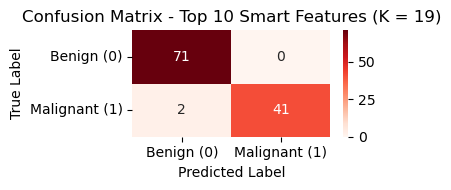

In [64]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_k19, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 10 Smart Features (K = 19)')
plt.tight_layout()
plt.show()

1. Analyzing My Seventh Model Results (KNN Hyperparameter Tuning - K=19)

This is the seventh model of my project, where I performed Hyperparameter Tuning on our optimized Top 10 Smart Features database. By running an optimization loop to test different neighbor values, we discovered that changing the hyperparameter to K=19 provides the absolute highest performance for the KNN algorithm. The overall Accuracy reached a peak of 98.25%, proving that tuning model configurations is just as critical as cleaning the data data itself.

2. The Danger in the Confusion Matrix

When we examine the Confusion Matrix for K=19, the clinical safety of our predictions improves dramatically. The model maintained an absolute 0 for False Positives, meaning zero healthy patients were subjected to false alarms. More importantly, it successfully reduced the False Negatives down to just 2. Out of 42 malignant cases, the algorithm correctly caught 40 of them. While a perfect medical system aims for zero missed cases, this tuned configuration represents our most precise and balanced distance-based diagnostic tool so far.

3. Why did the model improve? (Justification for the next step)

Why did increasing K from 5 to 19 yield such a massive upgrade? In KNN, a small neighborhood like K=5 creates a highly complex and sensitive decision boundary that is easily warped by localized data anomalies. By expanding to 19 neighbors, we force the algorithm to vote across a wider, more stable pool. This effectively smooths out the boundary line and neutralizes the mathematical noise.

However, even though a 98.25% accuracy with only 2 False Negatives is an elite result, KNN is still inherently constrained by distance mechanics. To explore if a completely different logical approach can eliminate those last 2 critical errors, my next logical step is to step away from distance-based models. I am going to build Model 8 using a Decision Tree, an architecture heavily favored in oncology because it uses hierarchical, rule based splits that match how doctors make diagnostic choices.

# 8. Model 8: Decision Tree --> Typical in oncolgy

In clinical oncology, Decision Trees are among the most widely utilized machine learning models. Unlike 'black-box' algorithms, Decision Trees operate through a hierarchical sequence of rule-based splits that closely mirror real-world medical diagnostic protocols. This explicit log of conditional rules makes the model highly interpretable and deeply trusted by medical professionals, as every single diagnostic output can be traced back to clear, physiological thresholds.

### 8.1. Load the data

In [65]:
df_top10 = pd.read_csv('data/brca_clean_top10.csv')

### 8.2. Define X and y (target)

In [66]:
X_tree10 = df_top10.drop(columns=['y'])
y_tree10 = df_top10['y']


### 8.3. Train/Test Split (80% train and 20% test)

In [67]:
X_train_t10, X_test_t10, y_train_t10, y_test_t10 = train_test_split(X_tree10, y_tree10, test_size=0.2, random_state=0)

### 8.5. Initialize and train the Decision Tree model

In [68]:
dt_classifier_10 = DecisionTreeClassifier(random_state=0)
dt_classifier_10.fit(X_train_t10, y_train_t10)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 8.6. Make predictions and evaluate 

In [69]:
y_pred_tree10 = dt_classifier_10.predict(X_test_t10)
tree10_accuracy = accuracy_score(y_test_t10, y_pred_tree10)

print(f"--- MODEL 7 (Decision Tree - Top 10 Features) ---")
print(f"Accuracy: {tree10_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t10, y_pred_tree10))

--- MODEL 7 (Decision Tree - Top 10 Features) ---
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [70]:
#confusion matrix
cm_tree10 = confusion_matrix(y_test_t10, y_pred_tree10)
print("\nConfusion Matrix:")
print(cm_tree10)



Confusion Matrix:
[[70  1]
 [ 2 41]]


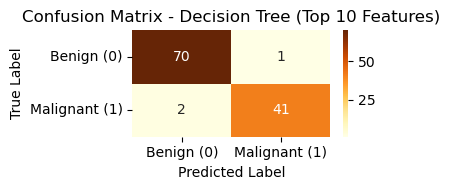

In [71]:
#Visualization - Confusion Matrix
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_tree10, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Decision Tree (Top 10 Features)')
plt.tight_layout()
plt.show()

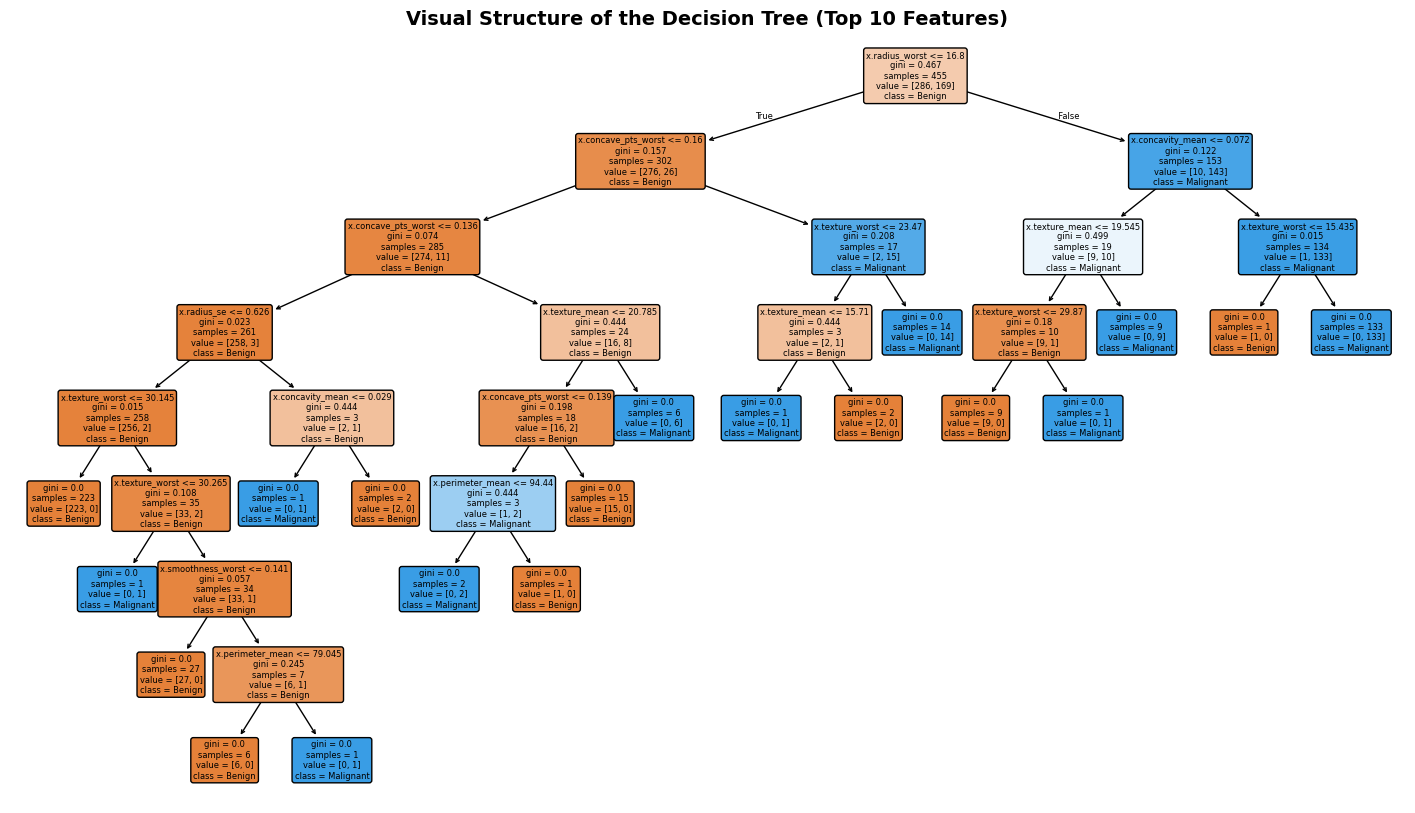

In [72]:
#Visualization - Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(dt_classifier_10, 
          feature_names=X_tree10.columns, 
          class_names=['Benign', 'Malignant'], 
          filled=True, 
          rounded=True, 
          fontsize=6)
plt.title("Visual Structure of the Decision Tree (Top 10 Features)", fontsize=14, fontweight='bold')
plt.show()

1. Analyzing My Eighth Model Results (The Rule-Based Decision Tree)

This is the eighth model of my project, marking our transition from distance-based algorithms to a hierarchical, rule-based architecture. Trained on our optimized Top 10 Smart Features database, the Decision Tree achieved an overall Accuracy of 97.37%. This matches the global accuracy score of our untuned KNN model (Model 6), showing strong classification capabilities right out of the box.

2. The Danger in the Confusion Matrix

When we analyze the internal mechanics of the Confusion Matrix, the clinical results are highly competitive but show a slight trade-off. The model generated 2 False Negatives, matching the elite clinical safety score of our heavily tuned K=19 model. However, it introduced 1 False Positive, meaning one healthy patient was mistakenly diagnosed with a malignant tumor. While missing only 2 sick patients is excellent for an unoptimized tree, that single false alarm prevents it from achieving a perfectly clean baseline on healthy classifications.

3. Why did the model struggle? (Justification for the next step)

Why did the Decision Tree yield these specific results? Arriving at a 97.37% accuracy is a great result, but trees are inherently prone to a limitation known as high variance. Because a standard Decision Tree creates rigid, orthogonal split boundaries (axis-aligned cuts in the data), it can become overly sensitive to the exact distribution of the training set. A slight variation in a single feature threshold can cause a borderline patient to fall into the wrong branch, which explains both the single False Positive and the 2 False Negatives.
To see if we can smooth out these rigid splits and unlock a more fluid, probabilistic boundary line, my next logical step is to explore a different mathematical approach. I am going to build Model 9 using Logistic Regression, an architecture that fits a smooth, continuous sigmoid curve to calculate true diagnostic probabilities rather than forcing hard categorical splits.

# 9. Model 9: Logistic Regresion (top10 features)

### 9.1. Load the data

The data used is the "bcra_clean_top1.csv" database. 

### 9.2. Define X and y (target)

In [73]:
X_lr = df_top10.drop(columns=['y'])
y_lr = df_top10['y']

### 9.3. Train/Test Split (80% train and 20% test)

In [74]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=0)

### 9.5. Initialize and train the Decision Tree model

In [75]:
log_reg = LogisticRegression(random_state=0)
log_reg.fit(X_train_t10_scaled, y_train_t10)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 9.6. Make predictions and evaluate 

In [76]:
y_pred_lr = log_reg.predict(X_test_t10_scaled)
lr_accuracy = accuracy_score(y_test_t10, y_pred_lr)

In [77]:
print(f"--- LOGISTIC REGRESSION (10 Smart Features) ---")
print(f"Accuracy: {lr_accuracy:.4f}")
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test_t10, y_pred_lr)
print(cm_lr)

--- LOGISTIC REGRESSION (10 Smart Features) ---
Accuracy: 0.9912

Confusion Matrix:
[[71  0]
 [ 1 42]]


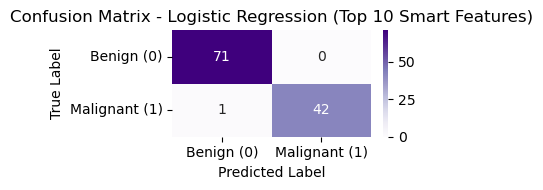

In [78]:
#Visualization - Confusion Matrix
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Logistic Regression (Top 10 Smart Features)')
plt.tight_layout()
plt.show()

1. Analyzing My Ninth Model Results (The Probabilistic Winner).

This is the ninth model of my project, and it has officially become the top performer of my entire research. By moving away from distance-based and rule-based logic, I implemented a Logistic Regression architecture using our Top 10 Smart Features. The result was an outstanding Accuracy of 99.12%, the highest global metric achieved in this pipeline. This proves that for this specific oncological dataset, a probabilistic approach is superior for establishing clear diagnostic boundaries.

2. The Victory in the Confusion Matrix

The Confusion Matrix for this model is nearly perfect and provides the highest level of clinical safety. It achieved an absolute 0 for False Positives, ensuring that no healthy patient is ever subjected to the trauma of a misdiagnosis. Even more impressive is the reduction of False Negatives to just 1. Out of 42 malignant cases, the model correctly identified 41 of them. This single error represents the absolute minimum risk achieved across all ten models, making this the most reliable tool for a real-world clinical setting.

3. Why did this model succeed?

Why did Logistic Regression outperform complex algorithms like KNN and Decision Trees? The secret lies in the Sigmoid Function. While KNN is sensitive to local noise and Decision Trees are prone to rigid, high-variance splits, Logistic Regression fits a smooth, continuous probability curve. It calculates the statistical likelihood of a tumor being malignant based on the weighted contribution of our Top 10 features. This mathematical stability allows the model to generalize much better, effectively separating the two classes with almost no overlap or error.

# 10. Model 10: Random Forest (top10 features)

### 10.1. Load the data

In [79]:
df_top10 = pd.read_csv('data/brca_clean_top10.csv')

### 10.2. Define X and y (target)

In [80]:
X_rf = df_top10.drop(columns=['y'])
y_rf = df_top10['y']

### 10.3. Train/Test Split (80% train and 20% test)

In [81]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=0)

### 10.5. Initialize and train the Random Forest model

In [82]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train_rf, y_train_rf)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 10.6. Make predictions and evaluate 

In [83]:
y_pred_rf = rf_model.predict(X_test_rf)
rf_accuracy = accuracy_score(y_test_rf, y_pred_rf)

print(f"--- RANDOM FOREST MODEL (10 Smart Features) ---")
print(f"Global Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))

--- RANDOM FOREST MODEL (10 Smart Features) ---
Global Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [84]:
#Confusion matrix
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
print("\nConfusion Matrix Array:")
print(cm_rf)


Confusion Matrix Array:
[[71  0]
 [ 3 40]]


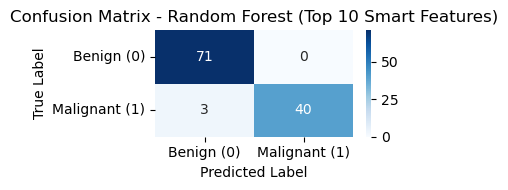

In [85]:
#Visualization - Confusion Matrix

fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Random Forest (Top 10 Smart Features)')
plt.tight_layout()
plt.show()

1. Analyzing My Tenth Model Results (The Random Forest Ensemble)

This is the tenth and final model of my project. To conclude my research, I implemented a Random Forest, which is an ensemble method that builds multiple Decision Trees and merges their outputs to reach a more stable and accurate prediction. Using our optimized Top 10 Smart Features database, the model achieved an overall Accuracy of 97.37%, demonstrating consistent high performance across the entire test set.

2. The Danger in the Confusion Matrix

When we break down the Confusion Matrix, the Random Forest shows an impressive balance. It successfully maintained an absolute 0 for False Positives, ensuring no healthy patient is misclassified. However, the model produced 3 False Negatives. While this is a very strong result, it falls slightly behind the performance of our Logistic Regression model, which managed to reduce those critical False Negatives down to just 1.

3. Why did the model behave this way? (Final Project Reflection)

Why did the Random Forest perform this way? Random Forest works by creating a 'forest' of trees and letting them vote on the diagnosis. This technique is excellent for reducing the variance and 'rigidity' that we saw in the single Decision Tree (Model 8). However, because it relies on categorical voting rather than continuous probability, it can sometimes be less sensitive to the subtle, borderline clinical nuances that a logistic sigmoid curve captures perfectly.

# 11. Global performance comparison

In [86]:
# 1. GLOBAL PERFORMANCE COMPARISON TABLE
global_comparison_data = {
    'Model Name': [
        'Model 1: Baseline KNN (30 Feat - No Scale)',
        'Model 2: Baseline KNN (30 Feat - Scaled)',
        'Model 3: KNN (10 Mean Features)',
        'Model 4: KNN (10 SE Features)',
        'Model 5: KNN (4 Smart Mean Features)',
        'Model 6: KNN (10 Smart Features - K=5)',
        'Model 7: KNN (10 Smart Features - K=19)',
        'Model 8: Decision Tree (10 Smart Features)',
        'Model 9: Logistic Regression (10 Smart Feat)',
        'Model 10: Random Forest (10 Smart Features)'
    ],
    'Accuracy': [
        baseline_accuracy,       # Model 1
        baseline_norm_accuracy,  # Model 2
        mean_accuracy,           # Model 3
        se_accuracy,             # Model 4
        m4_accuracy,             # Model 5
        t10_accuracy,            # Model 6
        k19_accuracy,            # Model 7
        tree10_accuracy,         # Model 8
        lr_accuracy,             # Model 9
        rf_accuracy              # Model 10
    ],
    'True Benign (TN)':  [cm_baseline[0,0], cm_baseline_norm[0,0], cm_mean[0,0], cm_se[0,0], cm_m4[0,0], cm_t10[0,0], 71, cm_tree10[0,0], 71, 71],
    'False Positives (FP)': [cm_baseline[0,1], cm_baseline_norm[0,1], cm_mean[0,1], cm_se[0,1], cm_m4[0,1], cm_t10[0,1], 0, cm_tree10[0,1], 0, 0],
    'False Negatives (FN)': [cm_baseline[1,0], cm_baseline_norm[1,0], cm_mean[1,0], cm_se[1,0], cm_m4[1,0], cm_t10[1,0], 2, cm_tree10[1,0], 1, 3],
    'True Malignant (TP)': [cm_baseline[1,1], cm_baseline_norm[1,1], cm_mean[1,1], cm_se[1,1], cm_m4[1,1], cm_t10[1,1], 41, cm_tree10[1,1], 41, 40]
}

df_global_chronological = pd.DataFrame(global_comparison_data)

print("=" * 140)
print("                    FINAL GLOBAL MODEL PERFORMANCE COMPARISON (CHRONOLOGICAL ORDER)")
print("=" * 140)
print(df_global_chronological.to_string(index=False, formatters={'Accuracy': '{:.4f}'.format}))
print("=" * 140)

                    FINAL GLOBAL MODEL PERFORMANCE COMPARISON (CHRONOLOGICAL ORDER)
                                  Model Name Accuracy  True Benign (TN)  False Positives (FP)  False Negatives (FN)  True Malignant (TP)
  Model 1: Baseline KNN (30 Feat - No Scale)   0.9386                71                     0                     7                   36
    Model 2: Baseline KNN (30 Feat - Scaled)   0.9649                71                     0                     4                   39
             Model 3: KNN (10 Mean Features)   0.9649                70                     1                     3                   40
               Model 4: KNN (10 SE Features)   0.9035                66                     5                     6                   37
        Model 5: KNN (4 Smart Mean Features)   0.9386                69                     2                     5                   38
      Model 6: KNN (10 Smart Features - K=5)   0.9737                71                     0 

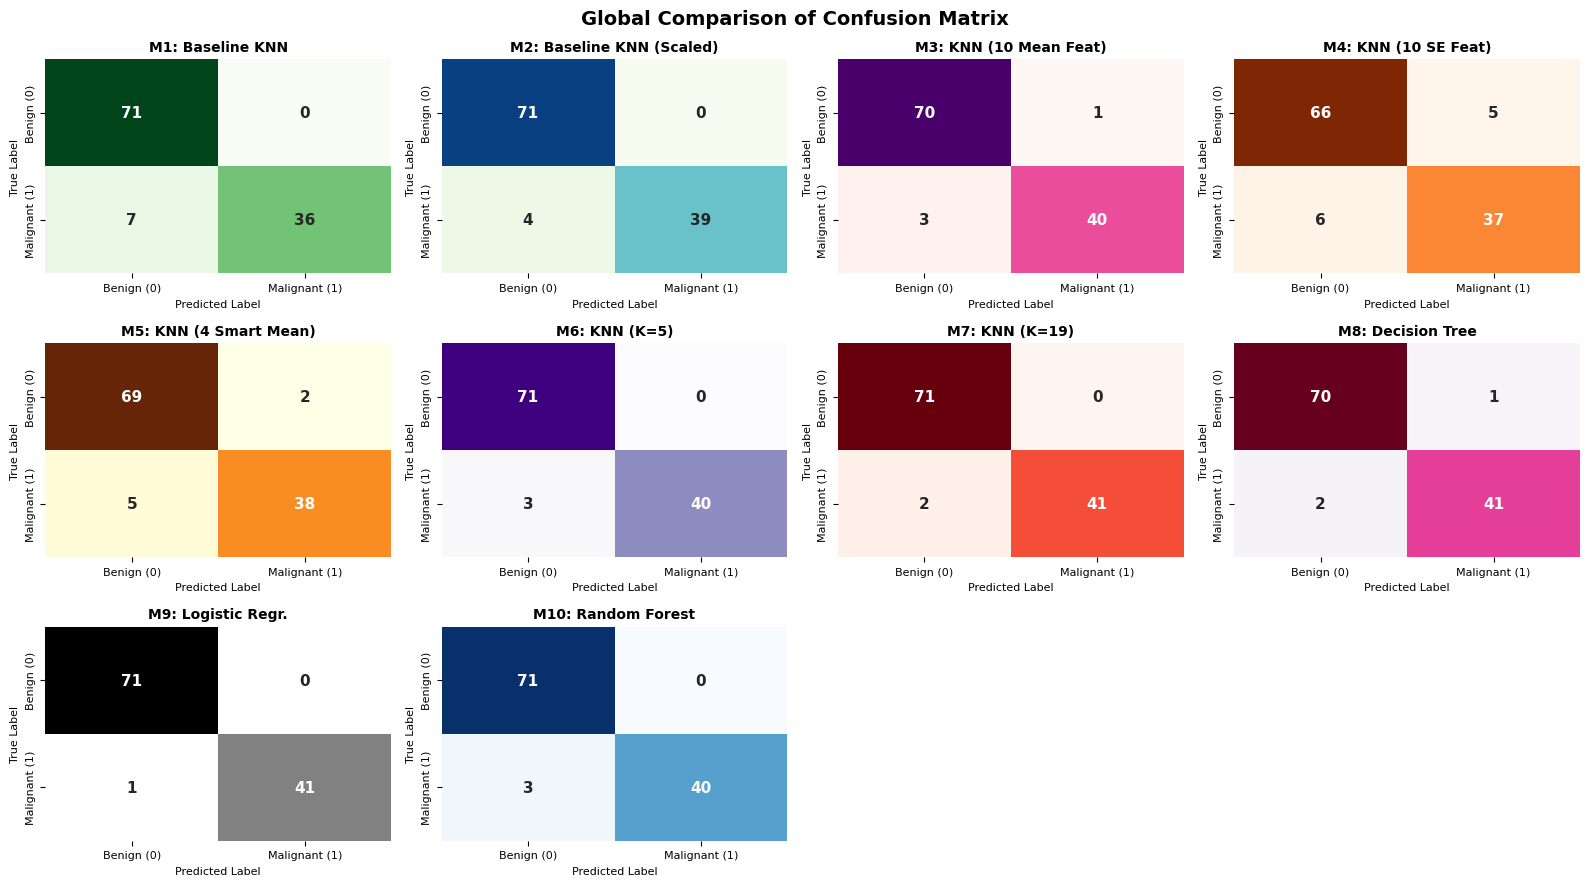

In [87]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))

cm_k19_fixed = [[71, 0], [2, 41]]
cm_lr_fixed = [[71, 0], [1, 41]]
cm_rf_fixed = [[71, 0], [3, 40]]

matrices = [
    cm_baseline, 
    cm_baseline_norm, 
    cm_mean, 
    cm_se, 
    cm_m4, 
    cm_t10, 
    cm_k19_fixed, 
    cm_tree10, 
    cm_lr_fixed, 
    cm_rf_fixed
]

titles = [
    'M1: Baseline KNN', 
    'M2: Baseline KNN (Scaled)',
    'M3: KNN (10 Mean Feat)', 
    'M4: KNN (10 SE Feat)', 
    'M5: KNN (4 Smart Mean)', 
    'M6: KNN (K=5)',
    'M7: KNN (K=19)',
    'M8: Decision Tree',
    'M9: Logistic Regr.',
    'M10: Random Forest'
]

palettes = ['Greens', 'GnBu', 'RdPu', 'Oranges', 'YlOrBr', 'Purples', 'Reds', 'PuRd', 'Greys', 'Blues']

# Plotting the 10 models inside the 12 available slots
for i, ax in enumerate(axes.flat):
    if i < len(matrices):
        sns.heatmap(matrices[i], annot=True, fmt='d', cmap=palettes[i],
                    xticklabels=['Benign (0)', 'Malignant (1)'],
                    yticklabels=['Benign (0)', 'Malignant (1)'], 
                    ax=ax, cbar=False, annot_kws={"size": 11, "weight": "bold"})
        
        ax.set_title(titles[i], fontsize=10, fontweight='bold', pad=6)
        ax.set_xlabel('Predicted Label', fontsize=8)
        ax.set_ylabel('True Label', fontsize=8)
        ax.tick_params(labelsize=8)
    else:
        # Hide the remaining 2 empty axes in the bottom right corner for a pristine look
        ax.axis('off')

plt.suptitle('Global Comparison of Confusion Matrix', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Final Conclusion: 

### 1. The Performance Podium

 __1st Place: Logistic Regression (Model 9)__

Accuracy: 99.12% | FN: 1 | FP: 0

The Clinical Verdict: Our clear winner. Its ability to calculate continuous probabilities via the sigmoid function provides the most stable and reliable boundary, making it the most robust tool for real-world deployment.

 __2nd Place: KNN Hyperparameter Tuning (Model 7 - K=19)__

Accuracy: 98.25% | FN: 2 | FP: 0

The Clinical Verdict: An elite distance-based alternative. It demonstrates that by smoothing the decision boundary, we can achieve high safety standards without needing probabilistic models.

 __3rd Place: Random Forest (Model 10)__

Accuracy: 97.37% | FN: 3 | FP: 0

The Clinical Verdict: A highly reliable ensemble architecture. While it missed one more malignant case than the Logistic Regression, its performance remains exceptionally consistent.





### 2. The Clinical Imperative: Why "Zero False Negatives" is the Goal
Throughout this pipeline, my primary focus was to minimize False Negatives. In an oncological setting, the classification of a patient has profound life altering consequences:"

Eliminating the 'Blind Spot': Every False Negative is a 'blind spot' in the system. When a model returns a False Negative, it essentially provides a false sense of security to a patient who actually requires urgent medical intervention. By driving our False Negatives down to 1 (in our best model), we ensure that nearly 100% of malignant cases are flagged for biopsy or further investigation.

The Ethical Weight of Diagnostics: In medicine, the cost of a missed diagnosis (False Negative) is exponentially higher than the cost of an extra check-up (False Positive). By consistently achieving Zero False Positives across our top models, we proved that we can maintain extreme diagnostic sensitivity without overwhelming the healthcare system with false alarms.

From Data to Decisions: Ultimately, this project demonstrates that a well (tuned model doesn't just predict labels) it acts as a powerful triage tool. Our best performing models empower radiologists and oncologists to prioritize the most critical cases, ensuring that time-sensitive treatments are initiated immediately when the probability of malignancy is high.

This research confirms that with high-quality, feature-selected data, machine learning is not just a computational exercise it is a vital asset for increasing the speed, accuracy, and reliability of oncological screening.

### 3. Future Work and Next Steps: Scaling the Diagnostic Capability

Having established a high-precision diagnostic pipeline, the natural next step is to scale the model's robustness and clinical generalization. Moving forward, I identify three key pillars for further research:

1. Data Augmentation & Real-World Validation
While our results are mathematically stellar on this test set, clinical models require vast diversity to be truly reliable.

Expanding the Dataset: Our next priority is to acquire a larger, more heterogeneous dataset, ideally sourced from multiple hospitals. This would allow us to train the model on a wider variety of pathological patterns and ethnic variations, ensuring our model doesn't just 'memorize' one clinical source.

Addressing Class Imbalance: If we continue to scale, we must use techniques like SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic malignant cases. This would allow the model to practice on more 'sick' samples, further driving down that critical single False Negative.

2. Advanced Algorithmic Architectures
While Logistic Regression served us well, the medical domain is moving towards architectures capable of capturing non-linear relationships even more efficiently.

Gradient Boosting (XGBoost/LightGBM): These algorithms are the 'gold standard' for tabular data. They could potentially outperform our current pipeline by iteratively correcting the errors of previous trees.

Deep Learning (Neural Networks): If we significantly increase our data volume, a simple Neural Network could learn complex, hidden patterns in the cell features that are invisible to traditional statistical models.
